# 01 · Exploratory Data Analysis

Extensive analysis of the IEEE-CIS Fraud dataset — class imbalance, transaction patterns,
card behaviour, feature distributions, KS tests, t-SNE and UMAP projections.

**Self-contained:** loads raw CSVs from `data/raw/`, no pipeline artefacts required.

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import gc, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0F1117", "axes.facecolor": "#1A1D27",
    "axes.edgecolor": "#2E3347", "text.color": "#E0E0E0",
    "axes.labelcolor": "#E0E0E0", "xtick.color": "#9AA0B0",
    "ytick.color": "#9AA0B0", "grid.color": "#2E3347",
    "grid.linestyle": "--", "font.family": "monospace",
    "figure.dpi": 120,
})
PAL = {"normal": "#4A90D9", "fraud": "#E84545", "accent": "#F5A623",
       "purple": "#A259FF", "green": "#4CAF50"}
print("Imports OK")


Imports OK


In [2]:
from pathlib import Path
# ── Change this to point to your repo root if running from elsewhere
REPO_ROOT = Path(".").resolve().parent  # assumes notebook is in notebooks/
DATA_DIR  = REPO_ROOT / "data" / "raw"
PROC_DIR  = REPO_ROOT / "data" / "processed"
MODEL_DIR = REPO_ROOT / "models"
OUT_DIR   = REPO_ROOT / "outputs"
for d in [PROC_DIR, MODEL_DIR, OUT_DIR]: d.mkdir(parents=True, exist_ok=True)
print(f"Data  : {DATA_DIR}")
print(f"Proc  : {PROC_DIR}")

Data  : /Users/MYOUSSF/Desktop/Projects/fraud_detection_project/data/raw
Proc  : /Users/MYOUSSF/Desktop/Projects/fraud_detection_project/data/processed


In [3]:
# ── Load and merge ────────────────────────────────────────────────────────────
print("Loading transactions ...")
tx = pd.read_csv(DATA_DIR / "train_transaction.csv")
print(f"  transactions : {tx.shape}")

print("Loading identity ...")
idf = pd.read_csv(DATA_DIR / "train_identity.csv")
print(f"  identity     : {idf.shape}")

df = tx.merge(idf, on="TransactionID", how="left")
df = df.rename(columns={"isFraud": "Class", "TransactionAmt": "Amount", "TransactionDT": "Time"})
df["user_id"] = df["card1"].fillna(0).astype(int)
df = df.sort_values(["user_id", "Time"]).reset_index(drop=True)
del tx, idf; gc.collect()

print(f"\nMerged: {df.shape}")
print(f"Fraud  : {df['Class'].sum():,} ({df['Class'].mean()*100:.3f}%)")
print(f"Cards  : {df['user_id'].nunique():,}")


Loading transactions ...
  transactions : (590540, 394)
Loading identity ...
  identity     : (144233, 41)

Merged: (590540, 435)
Fraud  : 20,663 (3.499%)
Cards  : 13,553


## 1 · Class distribution

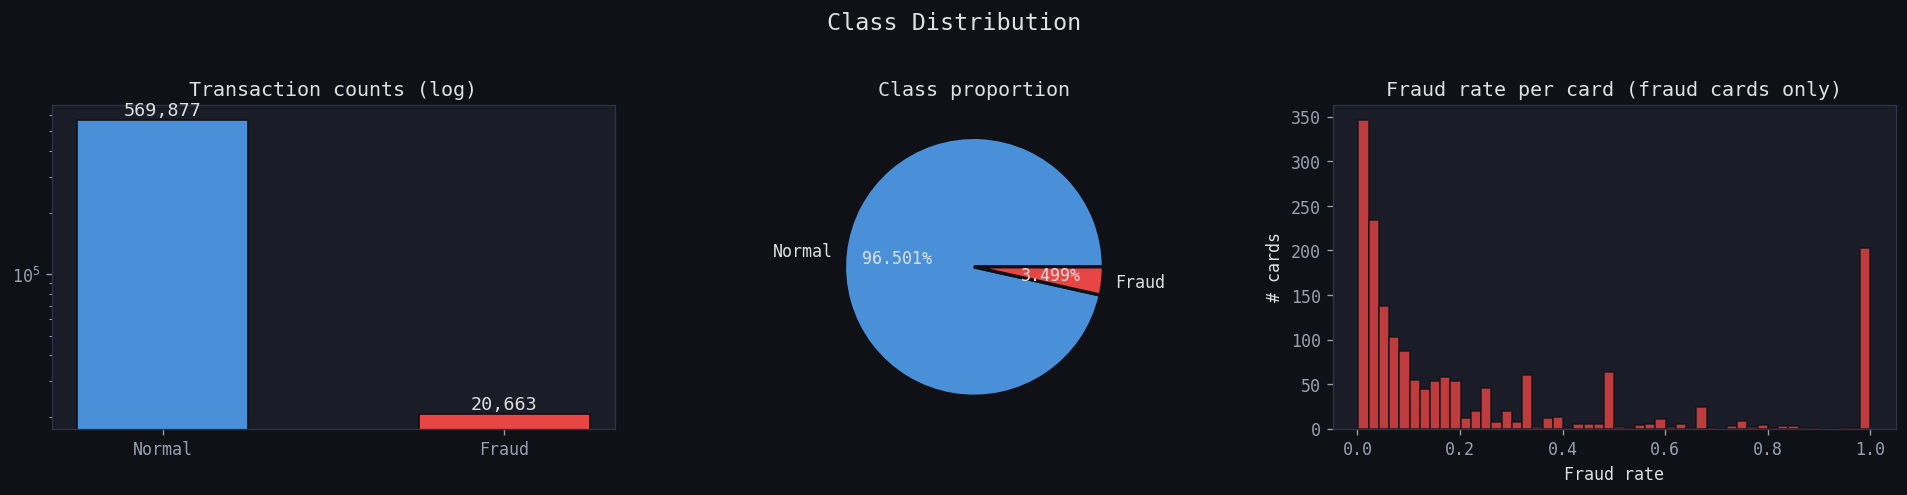

Cards with ≥1 fraud: 1,740 / 13,553


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor("#0F1117")
n_norm, n_fraud = (df["Class"] == 0).sum(), df["Class"].sum()

# Count bar
bars = axes[0].bar(["Normal", "Fraud"], [n_norm, n_fraud],
                   color=[PAL["normal"], PAL["fraud"]], edgecolor="#0F1117", width=0.5)
for b, v in zip(bars, [n_norm, n_fraud]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.05,
                 f"{v:,}", ha="center", color="#E0E0E0", fontsize=11)
axes[0].set_yscale("log"); axes[0].set_title("Transaction counts (log)", color="#E0E0E0")

# Pie
axes[1].pie([n_norm, n_fraud], labels=["Normal", "Fraud"],
            colors=[PAL["normal"], PAL["fraud"]], autopct="%1.3f%%",
            textprops={"color":"#E0E0E0"}, wedgeprops={"edgecolor":"#0F1117","linewidth":2})
axes[1].set_title("Class proportion", color="#E0E0E0")

# Fraud rate by card — distribution
card_fraud_rate = df.groupby("user_id")["Class"].mean()
axes[2].hist(card_fraud_rate[card_fraud_rate > 0], bins=50,
             color=PAL["fraud"], edgecolor="#0F1117", alpha=0.8)
axes[2].set_title("Fraud rate per card (fraud cards only)", color="#E0E0E0")
axes[2].set_xlabel("Fraud rate"); axes[2].set_ylabel("# cards")
plt.suptitle("Class Distribution", fontsize=14, color="#E0E0E0", y=1.02)
plt.tight_layout(); plt.show()
print(f"Cards with ≥1 fraud: {(card_fraud_rate>0).sum():,} / {len(card_fraud_rate):,}")


## 2 · Time analysis

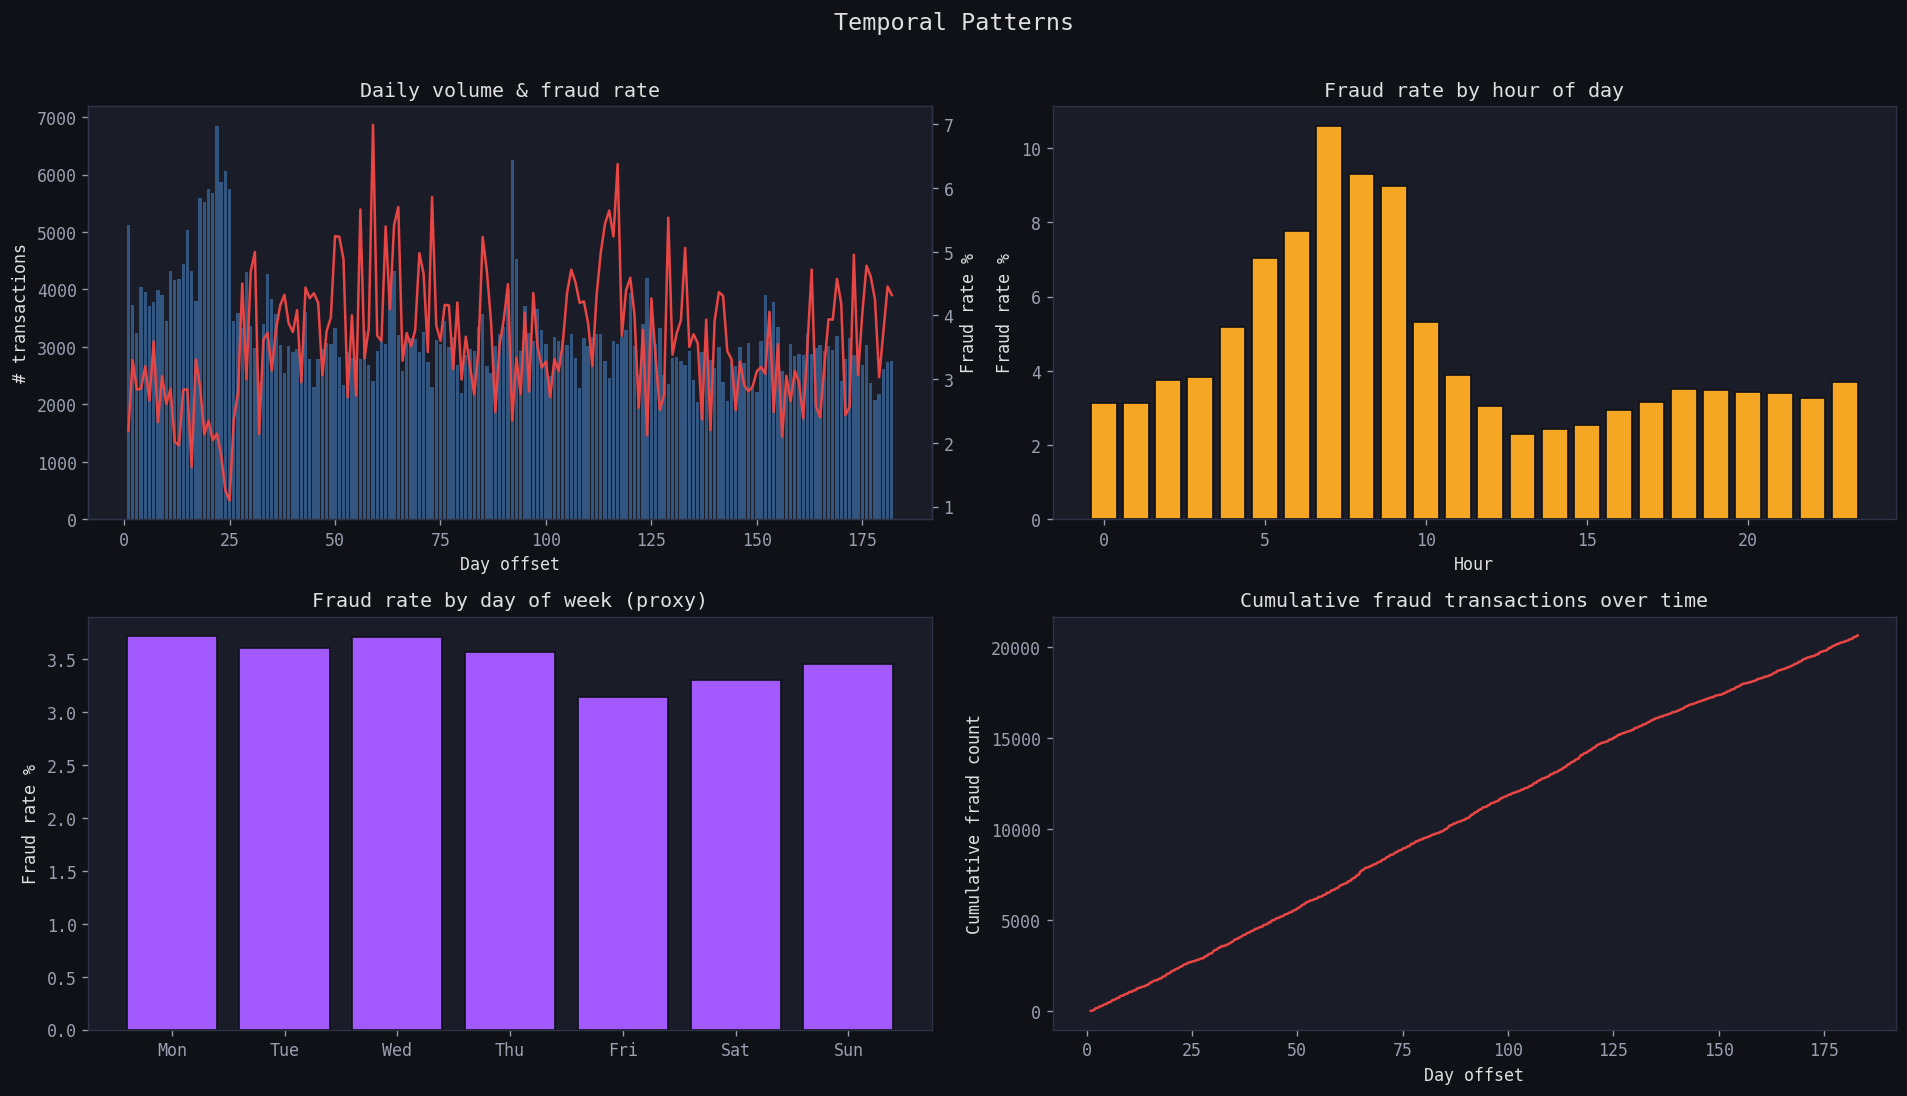

In [5]:
SECS = 86_400
df["day"]      = df["Time"] // SECS
df["hour"]     = (df["Time"] % SECS) // 3600
df["dow"]      = df["day"] % 7          # proxy day-of-week

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.patch.set_facecolor("#0F1117")

# Transaction volume over time
daily = df.groupby("day").agg(n=("Class","count"), fraud=("Class","sum"))
daily["fraud_rate"] = daily["fraud"] / daily["n"]
ax = axes[0,0]
ax2 = ax.twinx()
ax.bar(daily.index, daily["n"], color=PAL["normal"], alpha=0.5, label="Transactions")
ax2.plot(daily.index, daily["fraud_rate"]*100, color=PAL["fraud"], lw=1.5, label="Fraud rate %")
ax.set_title("Daily volume & fraud rate", color="#E0E0E0")
ax.set_xlabel("Day offset"); ax.set_ylabel("# transactions"); ax2.set_ylabel("Fraud rate %")

# Hourly fraud rate
hourly = df.groupby("hour")["Class"].mean() * 100
axes[0,1].bar(hourly.index, hourly.values, color=PAL["accent"], edgecolor="#0F1117")
axes[0,1].set_title("Fraud rate by hour of day", color="#E0E0E0")
axes[0,1].set_xlabel("Hour"); axes[0,1].set_ylabel("Fraud rate %")

# DOW fraud rate
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_rate = df.groupby("dow")["Class"].mean() * 100
axes[1,0].bar(range(len(dow_rate)), dow_rate.values, color=PAL["purple"], edgecolor="#0F1117")
axes[1,0].set_xticks(range(7)); axes[1,0].set_xticklabels(dow_labels)
axes[1,0].set_title("Fraud rate by day of week (proxy)", color="#E0E0E0")
axes[1,0].set_ylabel("Fraud rate %")

# Cumulative fraud over time
cum_fraud = df.sort_values("Time")["Class"].cumsum()
axes[1,1].plot(df.sort_values("Time")["Time"]/SECS, cum_fraud,
               color=PAL["fraud"], lw=1.5)
axes[1,1].set_title("Cumulative fraud transactions over time", color="#E0E0E0")
axes[1,1].set_xlabel("Day offset"); axes[1,1].set_ylabel("Cumulative fraud count")

plt.suptitle("Temporal Patterns", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


## 3 · Transaction amount analysis

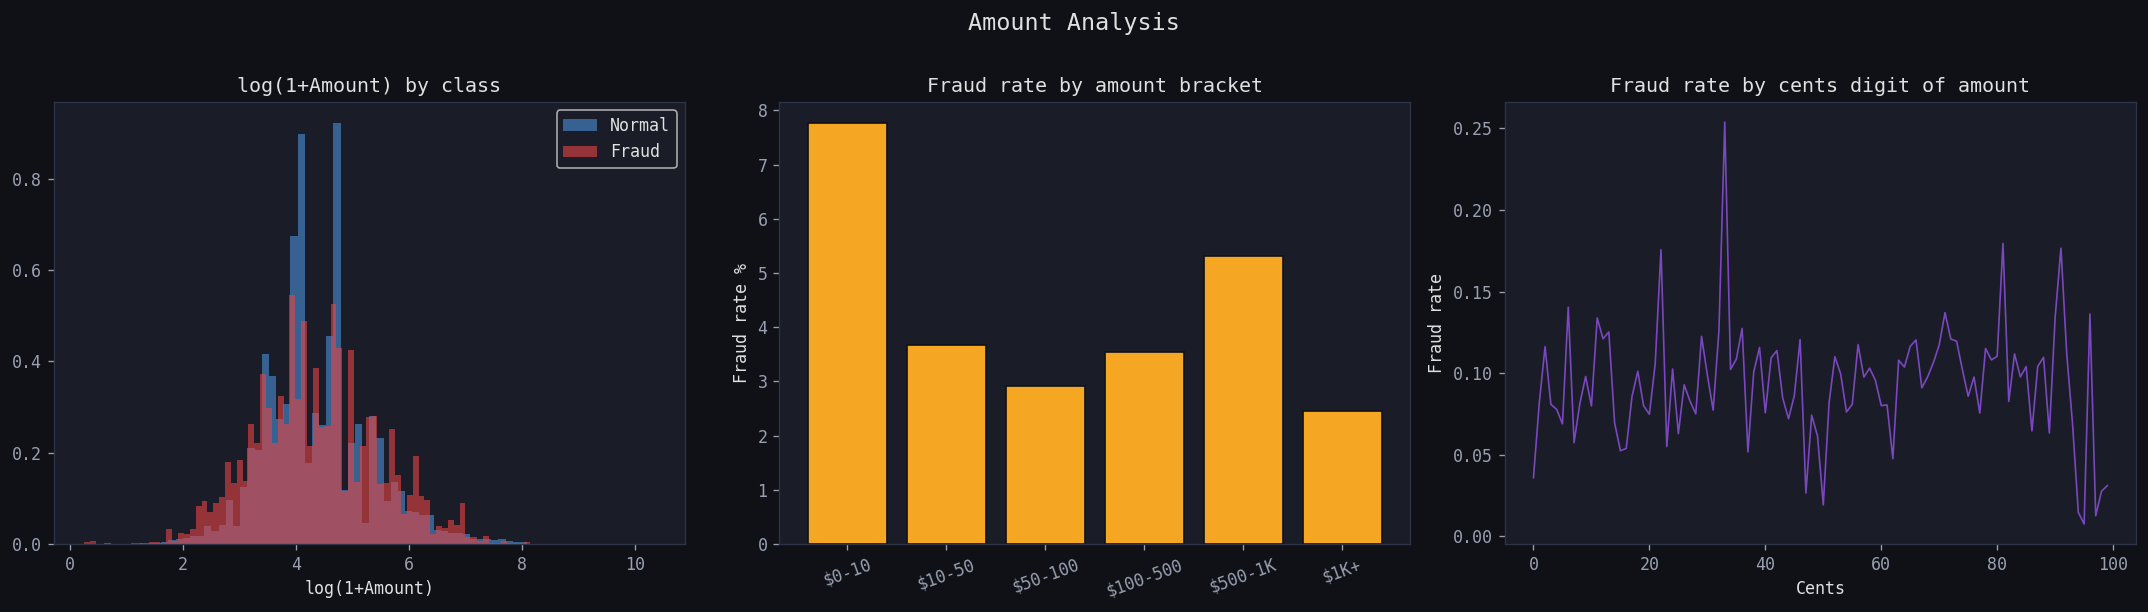

Median amount — Normal: $68.50  Fraud: $75.00


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0F1117")

# Log-amount distribution by class
for cls, lbl, col in [(0,"Normal",PAL["normal"]),(1,"Fraud",PAL["fraud"])]:
    vals = np.log1p(df[df["Class"]==cls]["Amount"].dropna())
    axes[0].hist(vals, bins=80, alpha=0.6, color=col, label=lbl, density=True)
axes[0].set_title("log(1+Amount) by class", color="#E0E0E0")
axes[0].set_xlabel("log(1+Amount)"); axes[0].legend()

# Amount bracket fraud rate
df["bracket"] = pd.cut(df["Amount"],
    bins=[0,10,50,100,500,1000,df["Amount"].max()+1],
    labels=["$0-10","$10-50","$50-100","$100-500","$500-1K","$1K+"])
br = df.groupby("bracket", observed=True)["Class"].agg(["mean","count"])
axes[1].bar(range(len(br)), br["mean"]*100, color=PAL["accent"], edgecolor="#0F1117")
axes[1].set_xticks(range(len(br))); axes[1].set_xticklabels(br.index, rotation=20)
axes[1].set_title("Fraud rate by amount bracket", color="#E0E0E0")
axes[1].set_ylabel("Fraud rate %")

# Cents digit — fraud fingerprint
df["cents"] = (df["Amount"] * 100).astype(int) % 100
cent_rate = df.groupby("cents")["Class"].mean()
axes[2].plot(cent_rate.index, cent_rate.values, color=PAL["purple"], lw=1, alpha=0.7)
axes[2].set_title("Fraud rate by cents digit of amount", color="#E0E0E0")
axes[2].set_xlabel("Cents"); axes[2].set_ylabel("Fraud rate")

plt.suptitle("Amount Analysis", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()

print("Median amount — Normal: ${:.2f}  Fraud: ${:.2f}".format(
    df[df["Class"]==0]["Amount"].median(), df[df["Class"]==1]["Amount"].median()))


## 4 · Card & product features

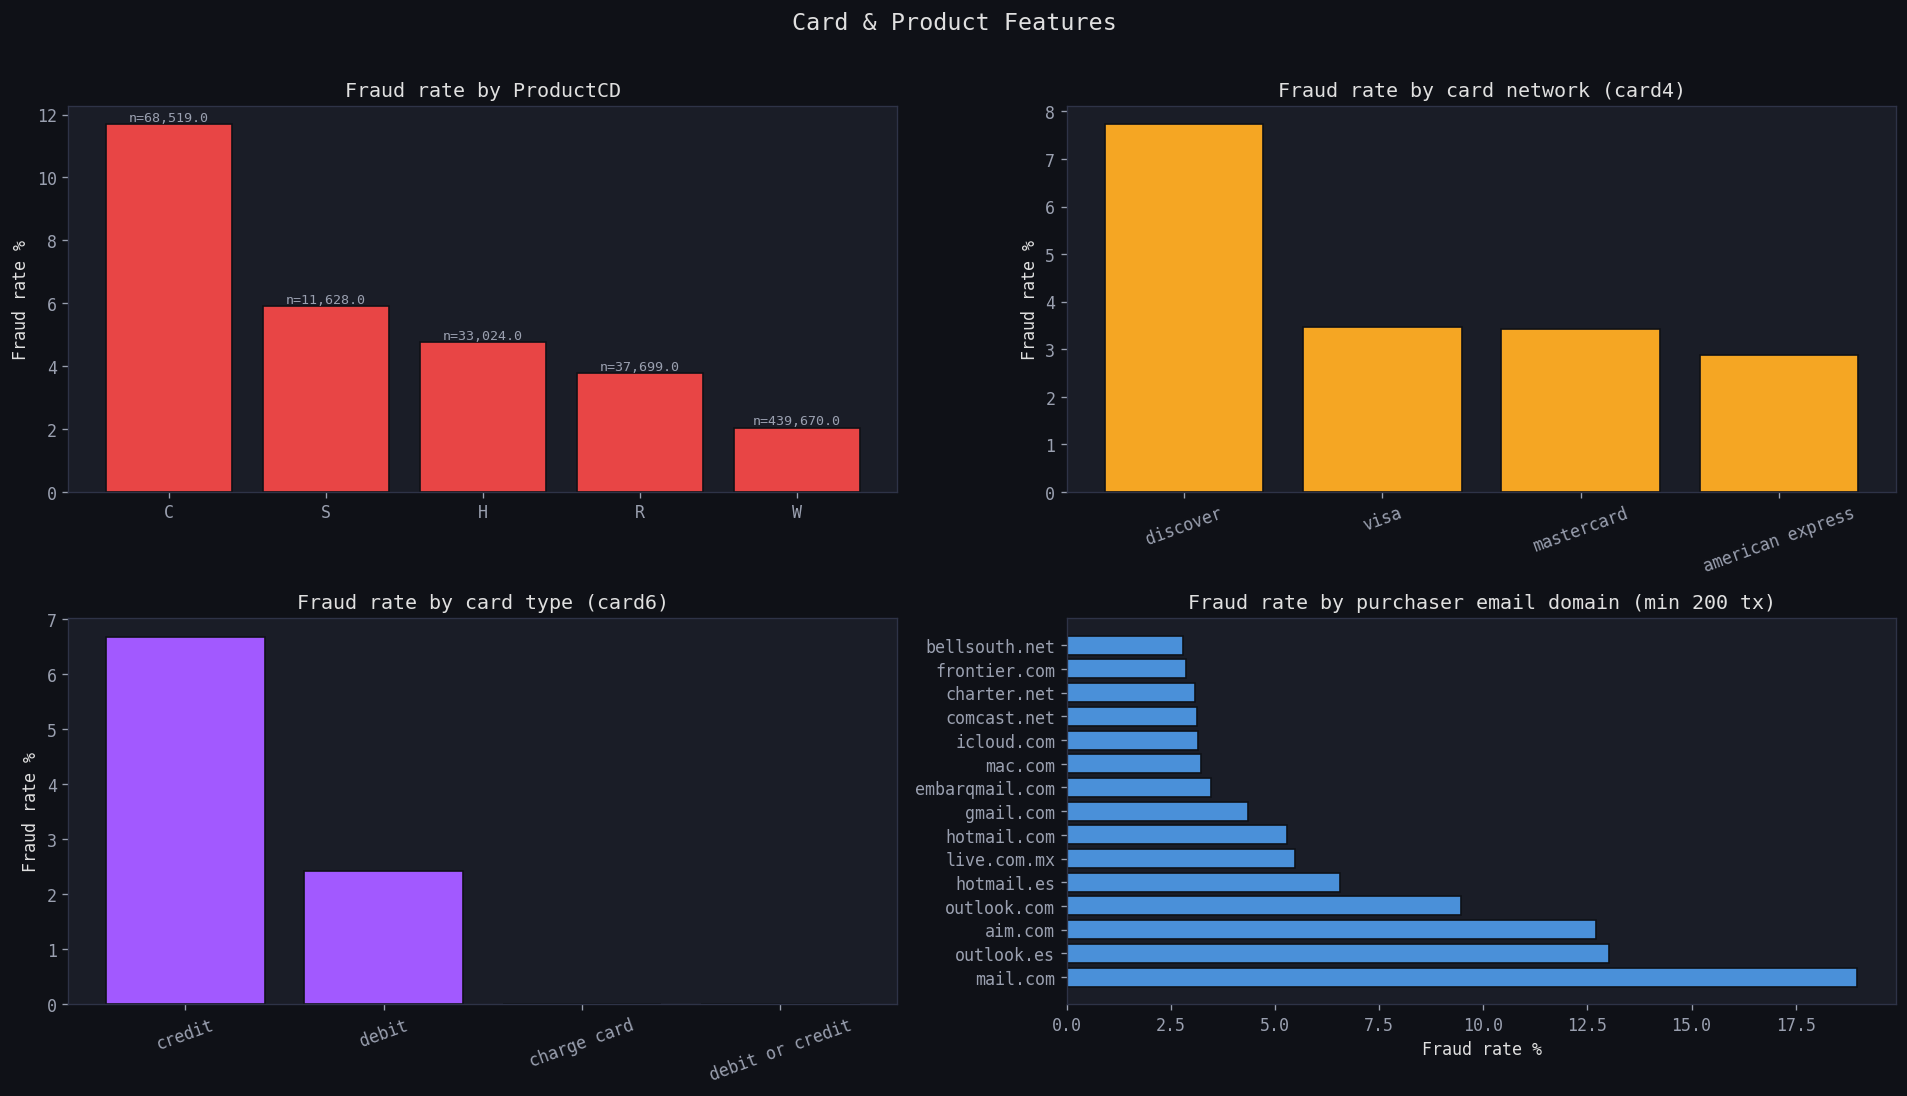

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.patch.set_facecolor("#0F1117")

# ProductCD fraud rate
prod = df.groupby("ProductCD")["Class"].agg(["mean","count"]).sort_values("mean", ascending=False)
axes[0,0].bar(prod.index, prod["mean"]*100, color=PAL["fraud"], edgecolor="#0F1117")
for i,(idx,row) in enumerate(prod.iterrows()):
    axes[0,0].text(i, row["mean"]*100+0.1, f"n={row['count']:,}", ha="center", fontsize=8, color="#9AA0B0")
axes[0,0].set_title("Fraud rate by ProductCD", color="#E0E0E0"); axes[0,0].set_ylabel("Fraud rate %")

# card4 (card network) fraud rate
if "card4" in df.columns:
    c4 = df.groupby("card4")["Class"].agg(["mean","count"]).sort_values("mean", ascending=False).head(8)
    axes[0,1].bar(c4.index, c4["mean"]*100, color=PAL["accent"], edgecolor="#0F1117")
    axes[0,1].set_title("Fraud rate by card network (card4)", color="#E0E0E0")
    axes[0,1].set_ylabel("Fraud rate %"); axes[0,1].tick_params(axis="x", rotation=20)

# card6 (debit/credit) fraud rate
if "card6" in df.columns:
    c6 = df.groupby("card6")["Class"].agg(["mean","count"]).sort_values("mean", ascending=False).head(6)
    axes[1,0].bar(c6.index, c6["mean"]*100, color=PAL["purple"], edgecolor="#0F1117")
    axes[1,0].set_title("Fraud rate by card type (card6)", color="#E0E0E0")
    axes[1,0].set_ylabel("Fraud rate %"); axes[1,0].tick_params(axis="x", rotation=20)

# Email domain fraud rate (top 15)
if "P_emaildomain" in df.columns:
    em = df.groupby("P_emaildomain")["Class"].agg(["mean","count"])
    em = em[em["count"] >= 200].sort_values("mean", ascending=False).head(15)
    axes[1,1].barh(em.index, em["mean"]*100, color=PAL["normal"], edgecolor="#0F1117")
    axes[1,1].set_title("Fraud rate by purchaser email domain (min 200 tx)", color="#E0E0E0")
    axes[1,1].set_xlabel("Fraud rate %")

plt.suptitle("Card & Product Features", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


## 5 · Missing value analysis

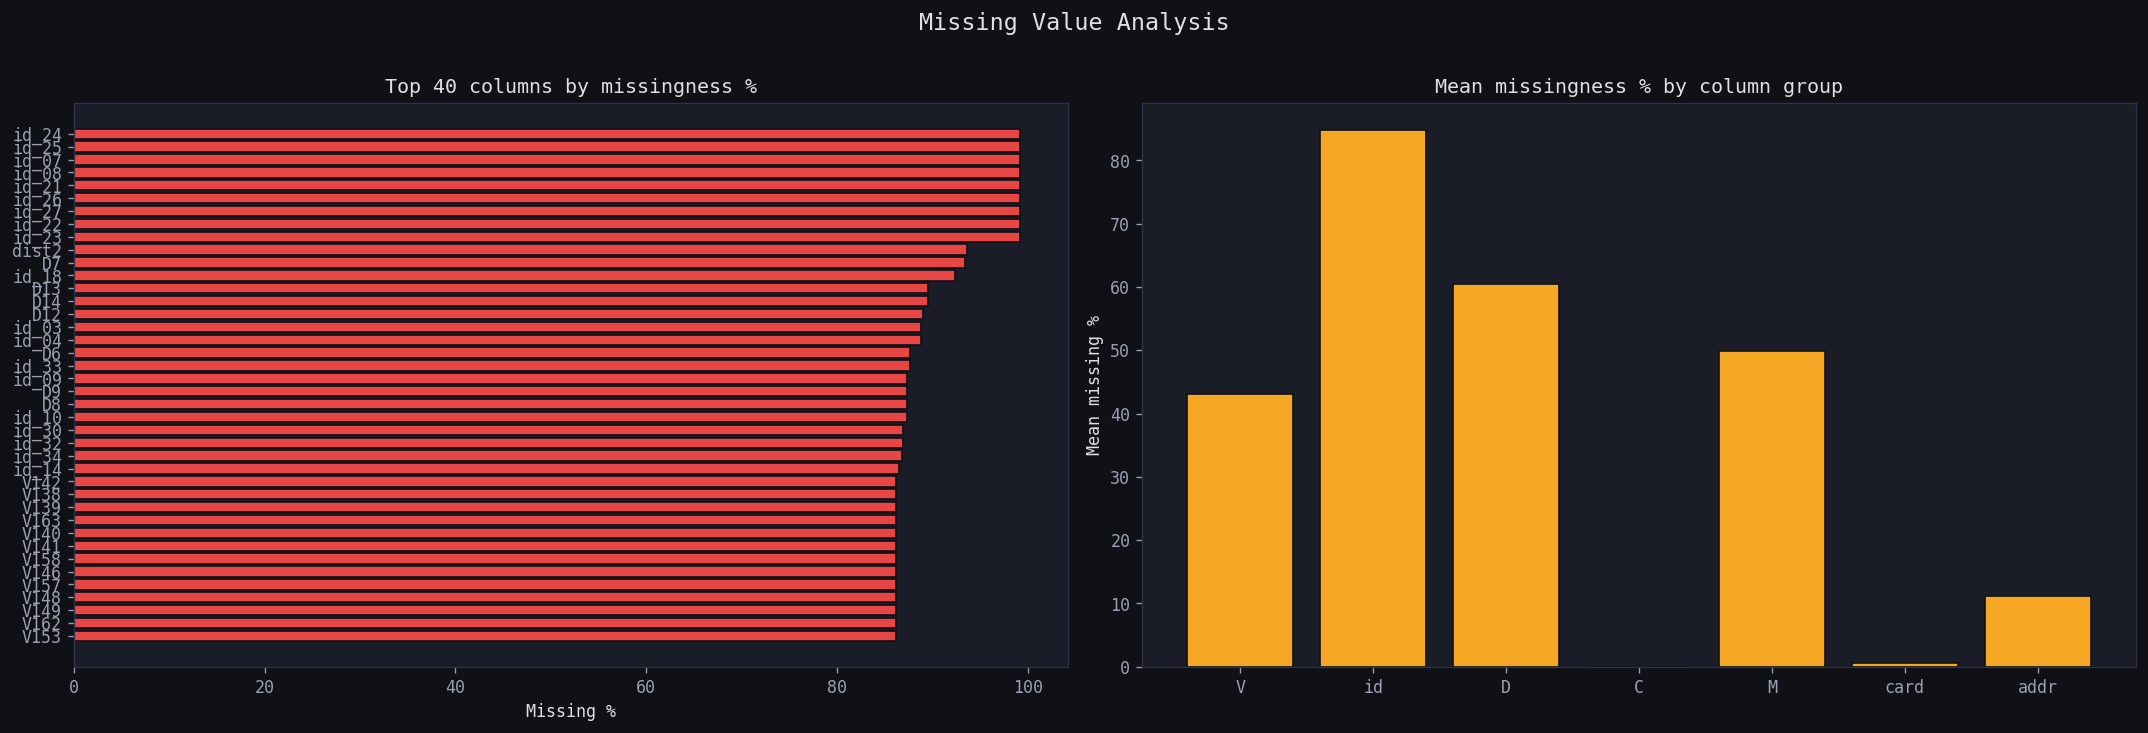

Columns with >50% missing: 214
Columns with >90% missing: 12


In [8]:
miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_top = miss[miss > 0].head(40)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor("#0F1117")

axes[0].barh(miss_top.index[::-1], miss_top.values[::-1], color=PAL["fraud"], edgecolor="#0F1117")
axes[0].set_title("Top 40 columns by missingness %", color="#E0E0E0")
axes[0].set_xlabel("Missing %")

# Distribution of missingness by column group
groups = {"V": miss[[c for c in miss.index if c.startswith("V")]].mean(),
          "id": miss[[c for c in miss.index if c.startswith("id")]].mean(),
          "D": miss[[c for c in miss.index if c.startswith("D")]].mean(),
          "C": miss[[c for c in miss.index if c.startswith("C")]].mean(),
          "M": miss[[c for c in miss.index if c.startswith("M")]].mean(),
          "card": miss[[c for c in miss.index if c.startswith("card")]].mean(),
          "addr": miss[[c for c in miss.index if c.startswith("addr")]].mean()}
axes[1].bar(groups.keys(), groups.values(), color=PAL["accent"], edgecolor="#0F1117")
axes[1].set_title("Mean missingness % by column group", color="#E0E0E0")
axes[1].set_ylabel("Mean missing %")

plt.suptitle("Missing Value Analysis", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()

print(f"Columns with >50% missing: {(miss > 50).sum()}")
print(f"Columns with >90% missing: {(miss > 90).sum()}")


## 6 · V-feature KS statistics

In [9]:
v_cols = [c for c in df.columns if c.startswith("V")][:28]
ks_results = []
for feat in v_cols:
    a = df.loc[df["Class"]==0, feat].dropna()
    b = df.loc[df["Class"]==1, feat].dropna()
    if len(a) > 10 and len(b) > 10:
        stat, pval = stats.ks_2samp(a, b)
        ks_results.append({"feature":feat, "ks_stat":stat, "p_value":pval,
                            "normal_mean":a.mean(), "fraud_mean":b.mean()})
ks_df = pd.DataFrame(ks_results).sort_values("ks_stat", ascending=False)
print(ks_df.to_string(index=False))


feature  ks_stat       p_value  normal_mean  fraud_mean
    V15 0.326545  0.000000e+00     0.111481    0.444564
    V16 0.326499  0.000000e+00     0.112487    0.448975
    V18 0.318001  0.000000e+00     0.122904    0.505007
    V17 0.317940  0.000000e+00     0.121817    0.496662
    V22 0.314724  0.000000e+00     0.121813    0.443193
    V21 0.314671  0.000000e+00     0.119351    0.436218
    V10 0.280564  0.000000e+00     0.469423    0.188667
    V11 0.280349  0.000000e+00     0.484609    0.198002
    V13 0.175923  0.000000e+00     0.603632    0.466679
    V12 0.172620  0.000000e+00     0.564623    0.413984
    V23 0.094160 1.116493e-125     1.027997    1.236350
    V24 0.093930 4.580223e-125     1.051152    1.264127
     V3 0.075490  4.099928e-30     1.075839    1.189813
     V5 0.069745  9.170005e-26     0.874506    1.001146
    V20 0.054642  1.477079e-42     0.844440    0.948796
     V9 0.053683  1.960928e-15     1.040315    1.102195
    V19 0.049286  1.064460e-34     0.813957    0

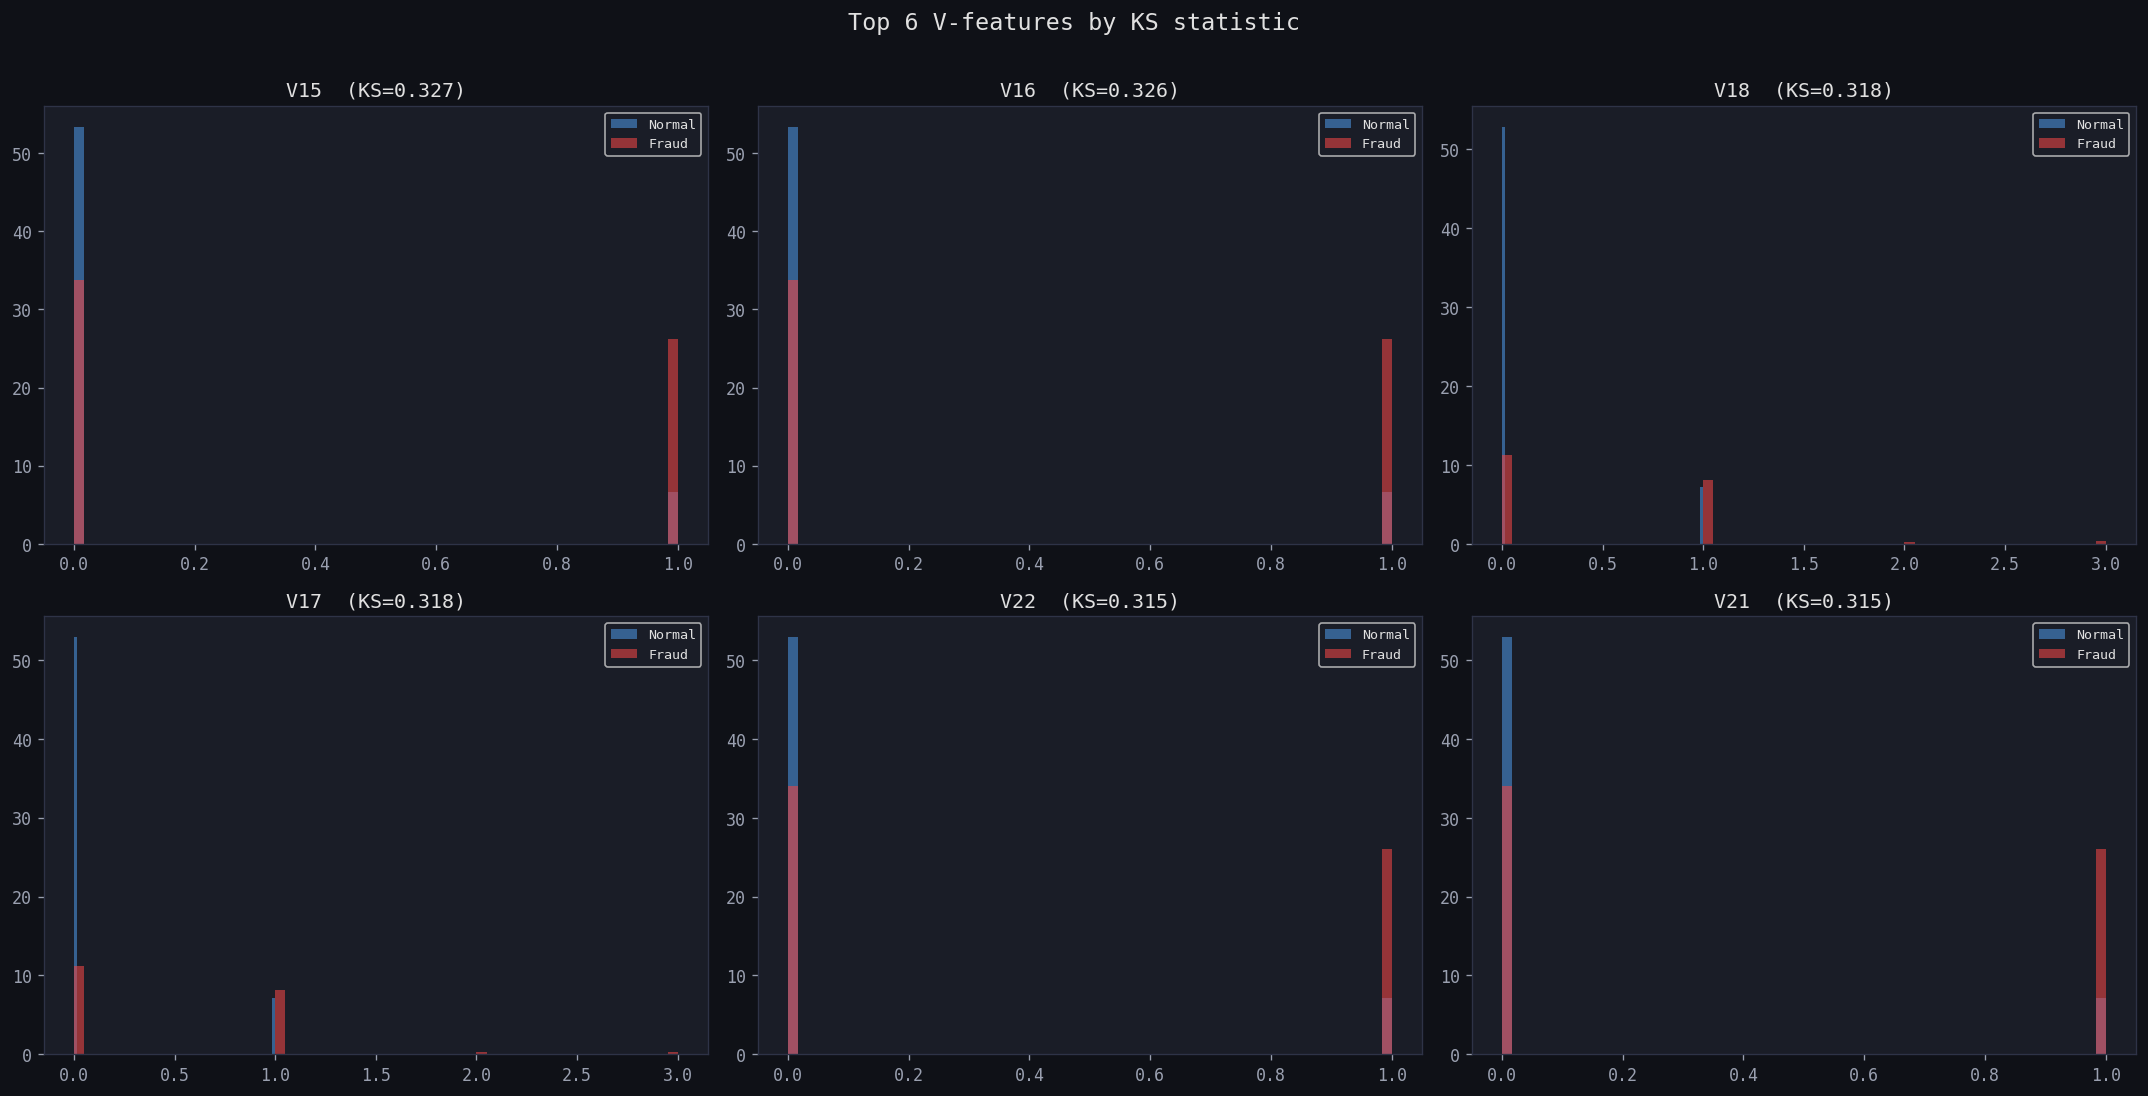

In [10]:
top6 = ks_df.head(6)["feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.patch.set_facecolor("#0F1117")
for ax, feat in zip(axes.flat, top6):
    ks_val = ks_df.loc[ks_df["feature"]==feat,"ks_stat"].values[0]
    for cls, lbl, col in [(0,"Normal",PAL["normal"]),(1,"Fraud",PAL["fraud"])]:
        vals = df[df["Class"]==cls][feat].dropna()
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        ax.hist(vals.clip(lo,hi), bins=60, alpha=0.6, color=col, label=lbl, density=True)
    ax.set_title(f"{feat}  (KS={ks_val:.3f})", color="#E0E0E0")
    ax.legend(fontsize=8)
plt.suptitle("Top 6 V-features by KS statistic", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


## 7 · Correlation heatmap (V-features)

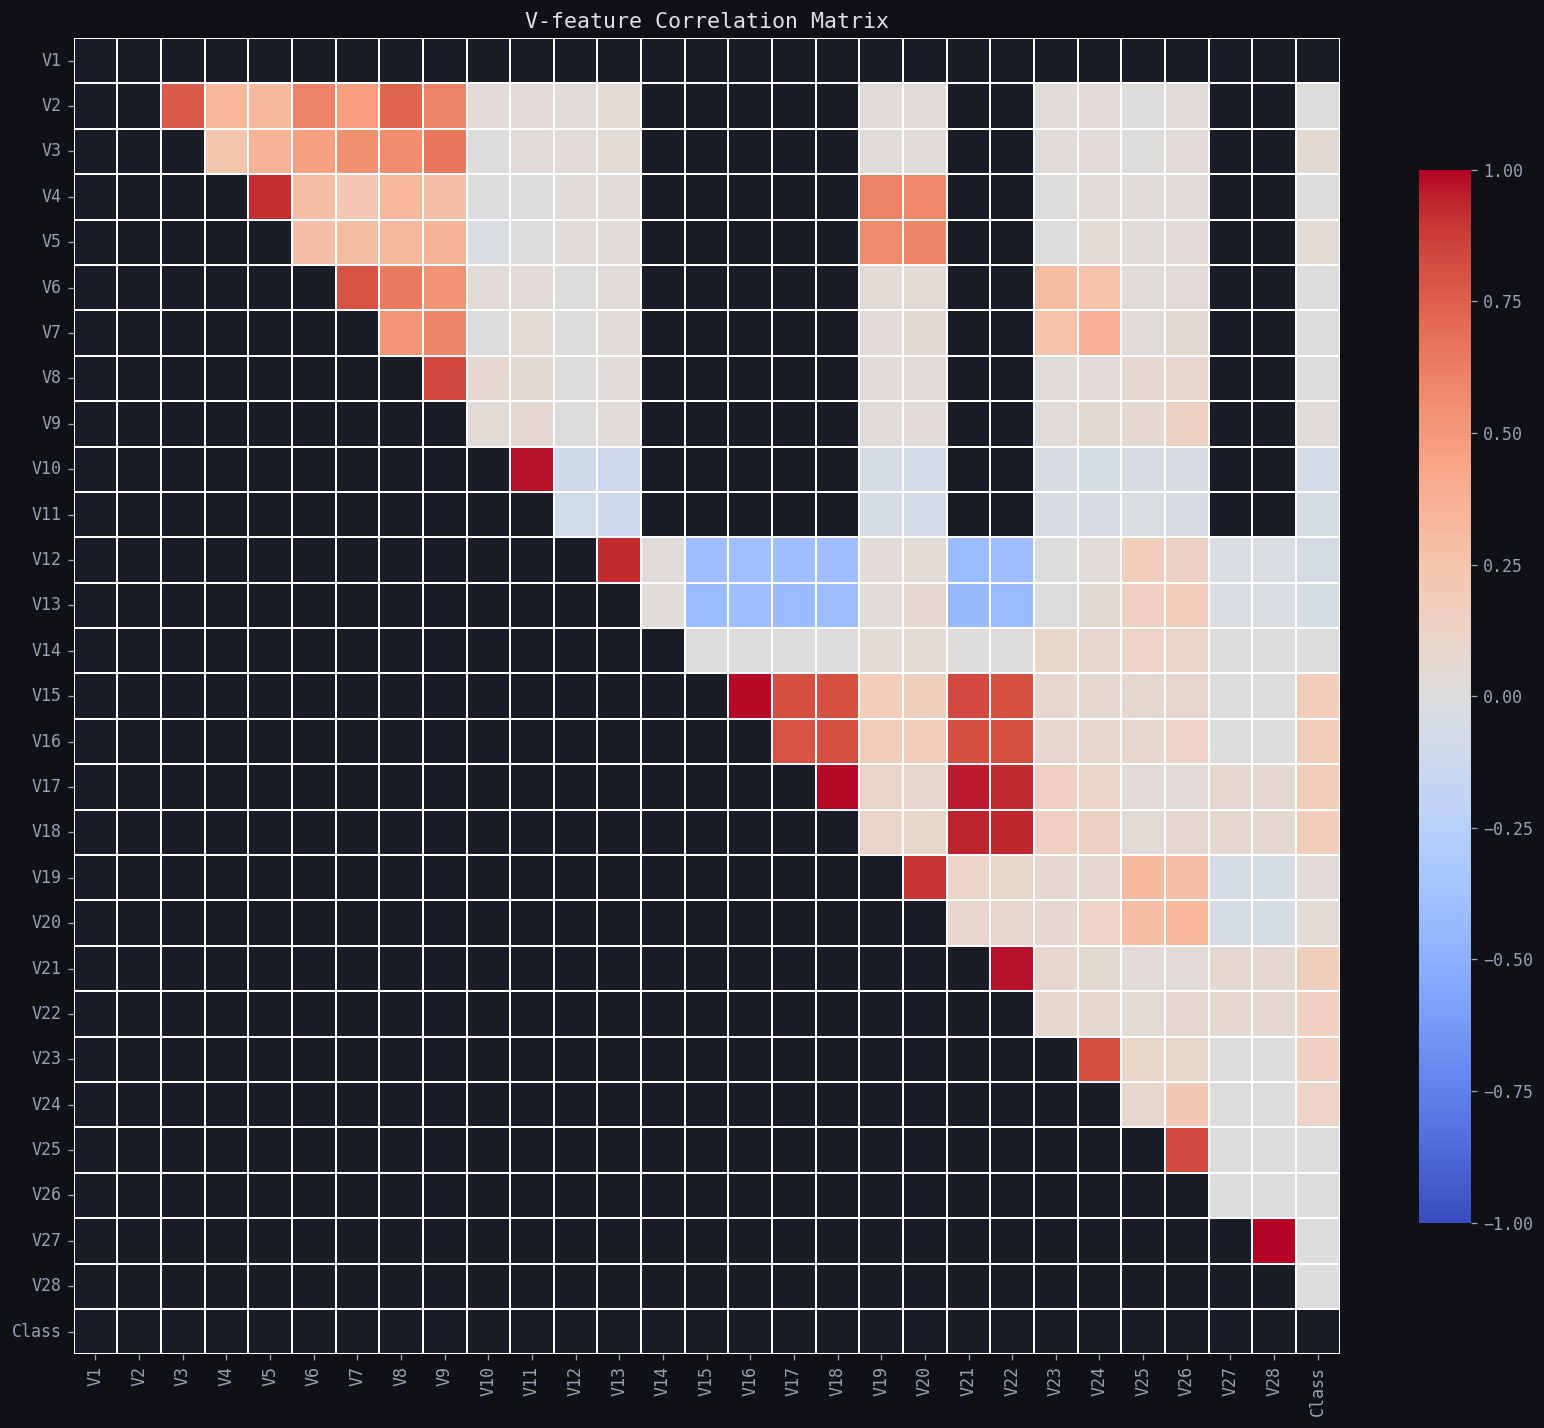


Top 10 V-features correlated with fraud:
V17    0.183961
V18    0.182571
V15    0.181496
V16    0.174641
V21    0.165352
V23    0.159561
V22    0.159141
V24    0.130510
V10    0.064239
V11    0.060774


In [11]:
v_sample = df[v_cols + ["Class"]].sample(n=min(50_000, len(df)), random_state=42)
corr = v_sample.corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor("#0F1117"); ax.set_facecolor("#1A1D27")
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr, mask=~mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            ax=ax, cbar_kws={"shrink":0.8}, linewidths=0.2)
ax.set_title("V-feature Correlation Matrix", color="#E0E0E0", fontsize=13)
plt.tight_layout(); plt.show()

# Top correlations with fraud label
fraud_corr = corr["Class"].drop("Class").abs().sort_values(ascending=False).head(10)
print("\nTop 10 V-features correlated with fraud:")
print(fraud_corr.to_string())


## 8 · Cardholder behaviour analysis

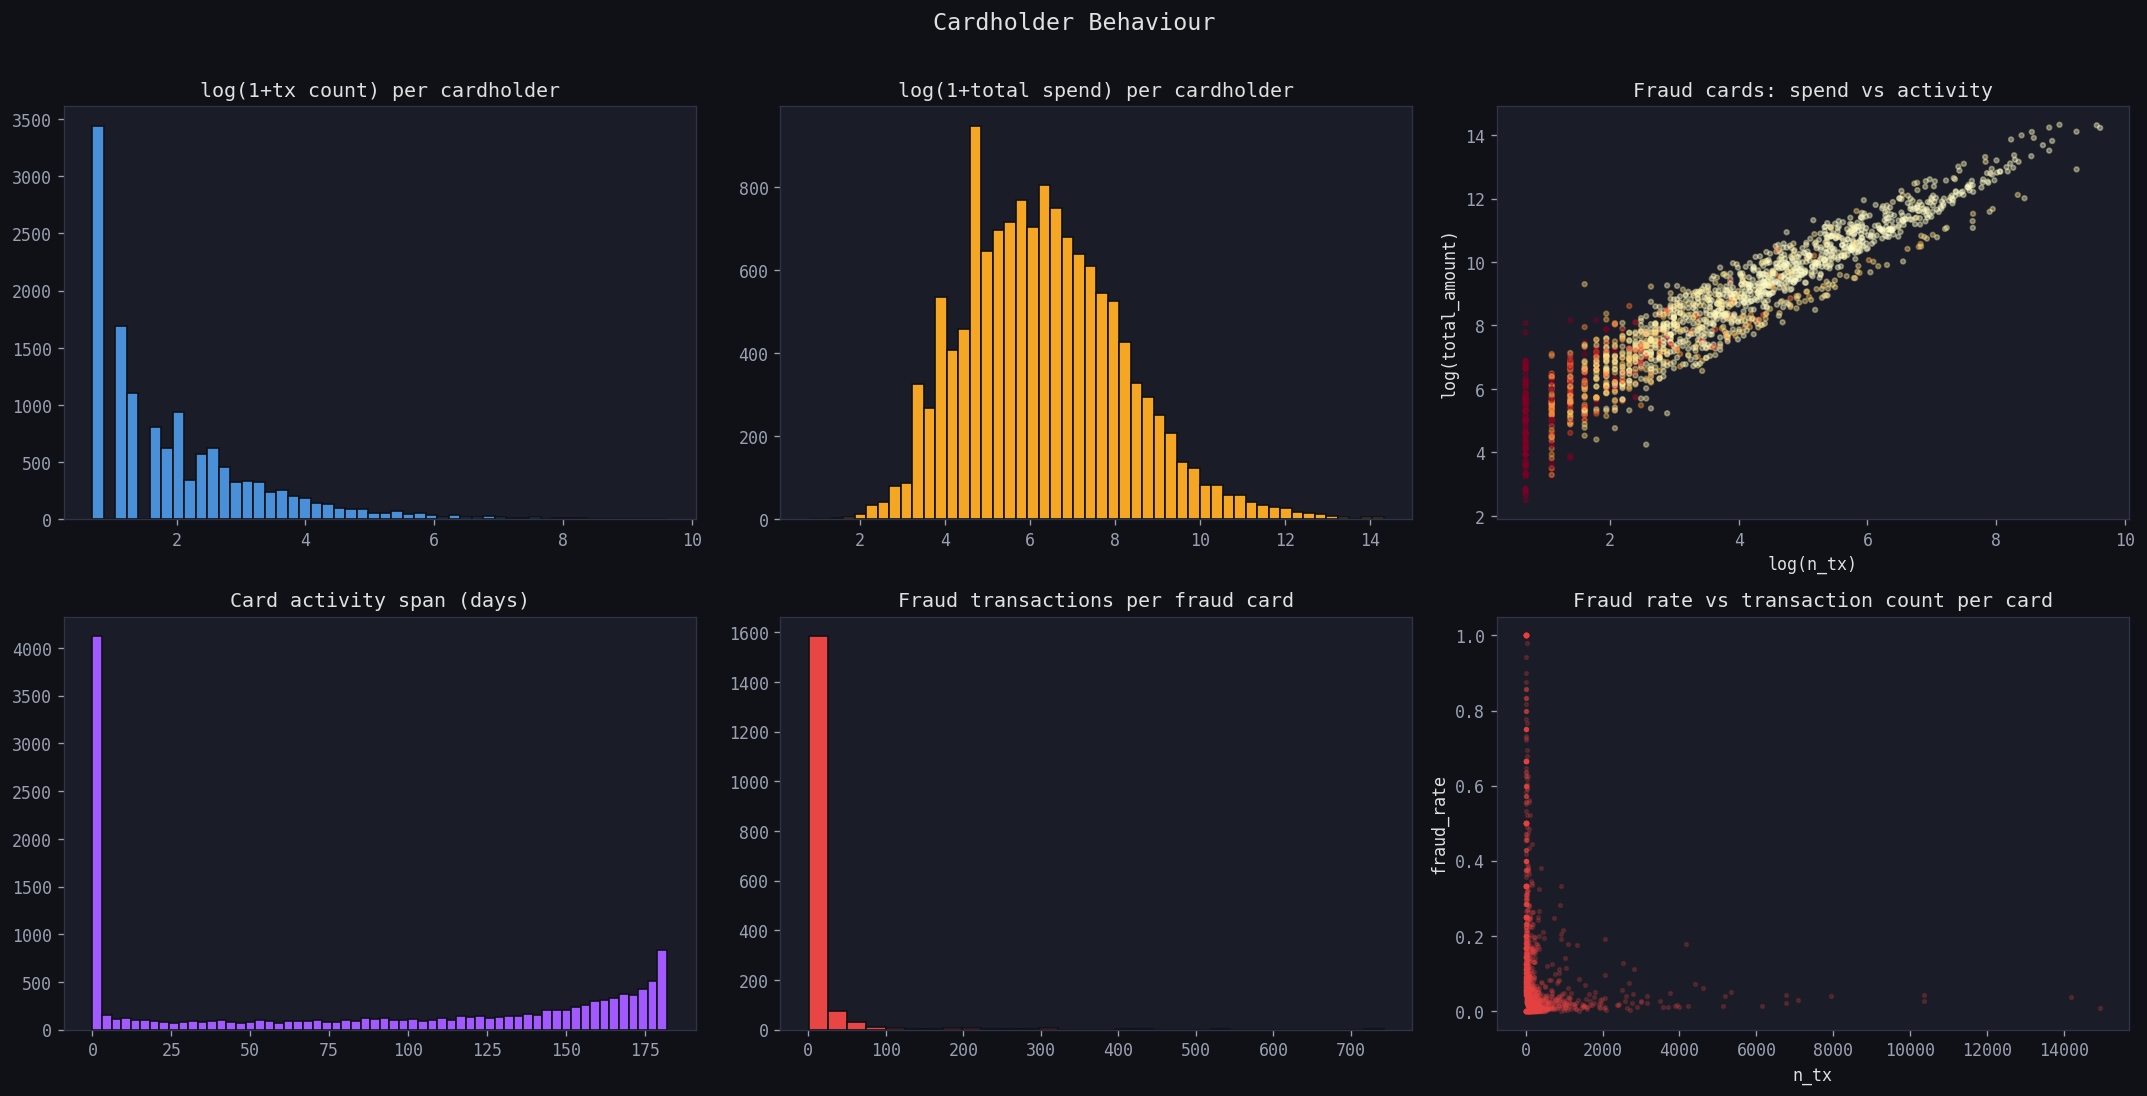

In [12]:
card_stats = df.groupby("user_id").agg(
    n_tx=("TransactionID","count"),
    total_amount=("Amount","sum"),
    mean_amount=("Amount","mean"),
    std_amount=("Amount","std"),
    n_fraud=("Class","sum"),
    fraud_rate=("Class","mean"),
    n_products=("ProductCD","nunique"),
    time_span=("Time", lambda x: x.max()-x.min()),
).fillna(0)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.patch.set_facecolor("#0F1117")

axes[0,0].hist(np.log1p(card_stats["n_tx"]), bins=50, color=PAL["normal"], edgecolor="#0F1117")
axes[0,0].set_title("log(1+tx count) per cardholder", color="#E0E0E0")

axes[0,1].hist(np.log1p(card_stats["total_amount"]), bins=50, color=PAL["accent"], edgecolor="#0F1117")
axes[0,1].set_title("log(1+total spend) per cardholder", color="#E0E0E0")

fraud_cards = card_stats[card_stats["fraud_rate"] > 0]
axes[0,2].scatter(np.log1p(fraud_cards["n_tx"]),
                  np.log1p(fraud_cards["total_amount"]),
                  c=fraud_cards["fraud_rate"], cmap="YlOrRd", alpha=0.4, s=8)
axes[0,2].set_title("Fraud cards: spend vs activity", color="#E0E0E0")
axes[0,2].set_xlabel("log(n_tx)"); axes[0,2].set_ylabel("log(total_amount)")

axes[1,0].hist(card_stats["time_span"]/86400, bins=60, color=PAL["purple"], edgecolor="#0F1117")
axes[1,0].set_title("Card activity span (days)", color="#E0E0E0")

axes[1,1].hist(card_stats[card_stats["n_fraud"]>0]["n_fraud"], bins=30,
               color=PAL["fraud"], edgecolor="#0F1117")
axes[1,1].set_title("Fraud transactions per fraud card", color="#E0E0E0")

axes[1,2].scatter(card_stats["n_tx"], card_stats["fraud_rate"],
                  alpha=0.2, s=5, color=PAL["fraud"])
axes[1,2].set_title("Fraud rate vs transaction count per card", color="#E0E0E0")
axes[1,2].set_xlabel("n_tx"); axes[1,2].set_ylabel("fraud_rate")

plt.suptitle("Cardholder Behaviour", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


## 9 · t-SNE projection

> Uses a stratified sample of 3,000 transactions (1,500 fraud + 1,500 normal) on scaled V-features. May take 1–3 minutes.

In [13]:
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE

N_SAMPLE = 3_000
rng = np.random.default_rng(42)
fraud_idx  = np.where(df["Class"].values == 1)[0]
normal_idx = np.where(df["Class"].values == 0)[0]
n_f = min(N_SAMPLE // 2, len(fraud_idx))
n_n = min(N_SAMPLE - n_f, len(normal_idx))
idx = np.concatenate([rng.choice(fraud_idx, n_f, replace=False),
                      rng.choice(normal_idx, n_n, replace=False)])

v_cols_tsne = [c for c in df.columns if c.startswith("V")][:28]
X_tsne = df.iloc[idx][v_cols_tsne].fillna(0).values
y_tsne = df.iloc[idx]["Class"].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_tsne)
X_scaled = np.clip(X_scaled, -5, 5)

print(f"Running t-SNE on {len(idx):,} samples  ({n_f} fraud, {n_n} normal) ...")
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=40, learning_rate="auto",
            init="pca", random_state=42, n_jobs=-1)
Z_tsne = tsne.fit_transform(X_scaled)
print(f"t-SNE done in {time.time()-t0:.1f}s")


Running t-SNE on 3,000 samples  (1500 fraud, 1500 normal) ...
t-SNE done in 5.9s


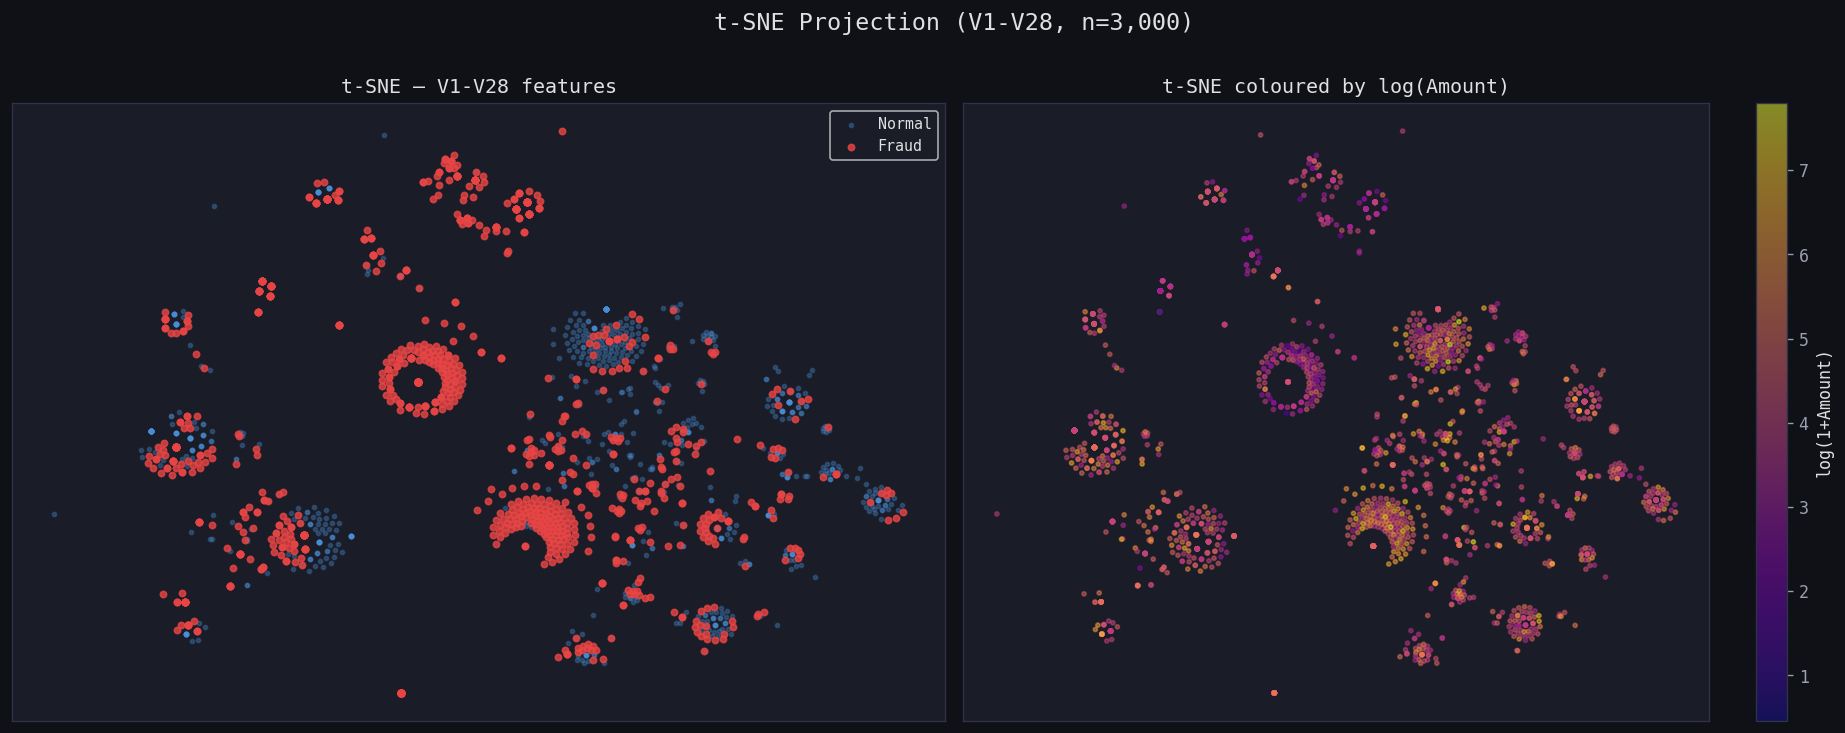

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0F1117")

for ax, (cls, lbl, col) in zip([axes[0], axes[0]], [(0,"Normal",PAL["normal"]),(1,"Fraud",PAL["fraud"])]):
    pass  # drawn together below

mask_n = y_tsne == 0; mask_f = y_tsne == 1
axes[0].scatter(Z_tsne[mask_n, 0], Z_tsne[mask_n, 1], c=PAL["normal"], s=6, alpha=0.3, label="Normal")
axes[0].scatter(Z_tsne[mask_f, 0], Z_tsne[mask_f, 1], c=PAL["fraud"],  s=14, alpha=0.8, label="Fraud")
axes[0].set_title("t-SNE — V1-V28 features", color="#E0E0E0")
axes[0].legend(fontsize=9)
axes[0].set_xticks([]); axes[0].set_yticks([])

# Colour by log(Amount)
amt_sample = np.log1p(df.iloc[idx]["Amount"].fillna(0).values)
sc = axes[1].scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=amt_sample,
                     cmap="plasma", s=6, alpha=0.5)
plt.colorbar(sc, ax=axes[1], label="log(1+Amount)")
axes[1].set_title("t-SNE coloured by log(Amount)", color="#E0E0E0")
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.suptitle("t-SNE Projection (V1-V28, n=3,000)", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


## 10 · UMAP projection

> Same sample as t-SNE. Typically faster and preserves global structure better.

In [15]:
try:
    import umap
    print(f"umap-learn version: {umap.__version__}")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn", "-q"])
    import umap

print(f"Running UMAP on {len(idx):,} samples ...")
t0 = time.time()
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    metric="euclidean", random_state=42, n_jobs=-1)
Z_umap = reducer.fit_transform(X_scaled)
print(f"UMAP done in {time.time()-t0:.1f}s")


umap-learn version: 0.5.12
Running UMAP on 3,000 samples ...
UMAP done in 28.2s


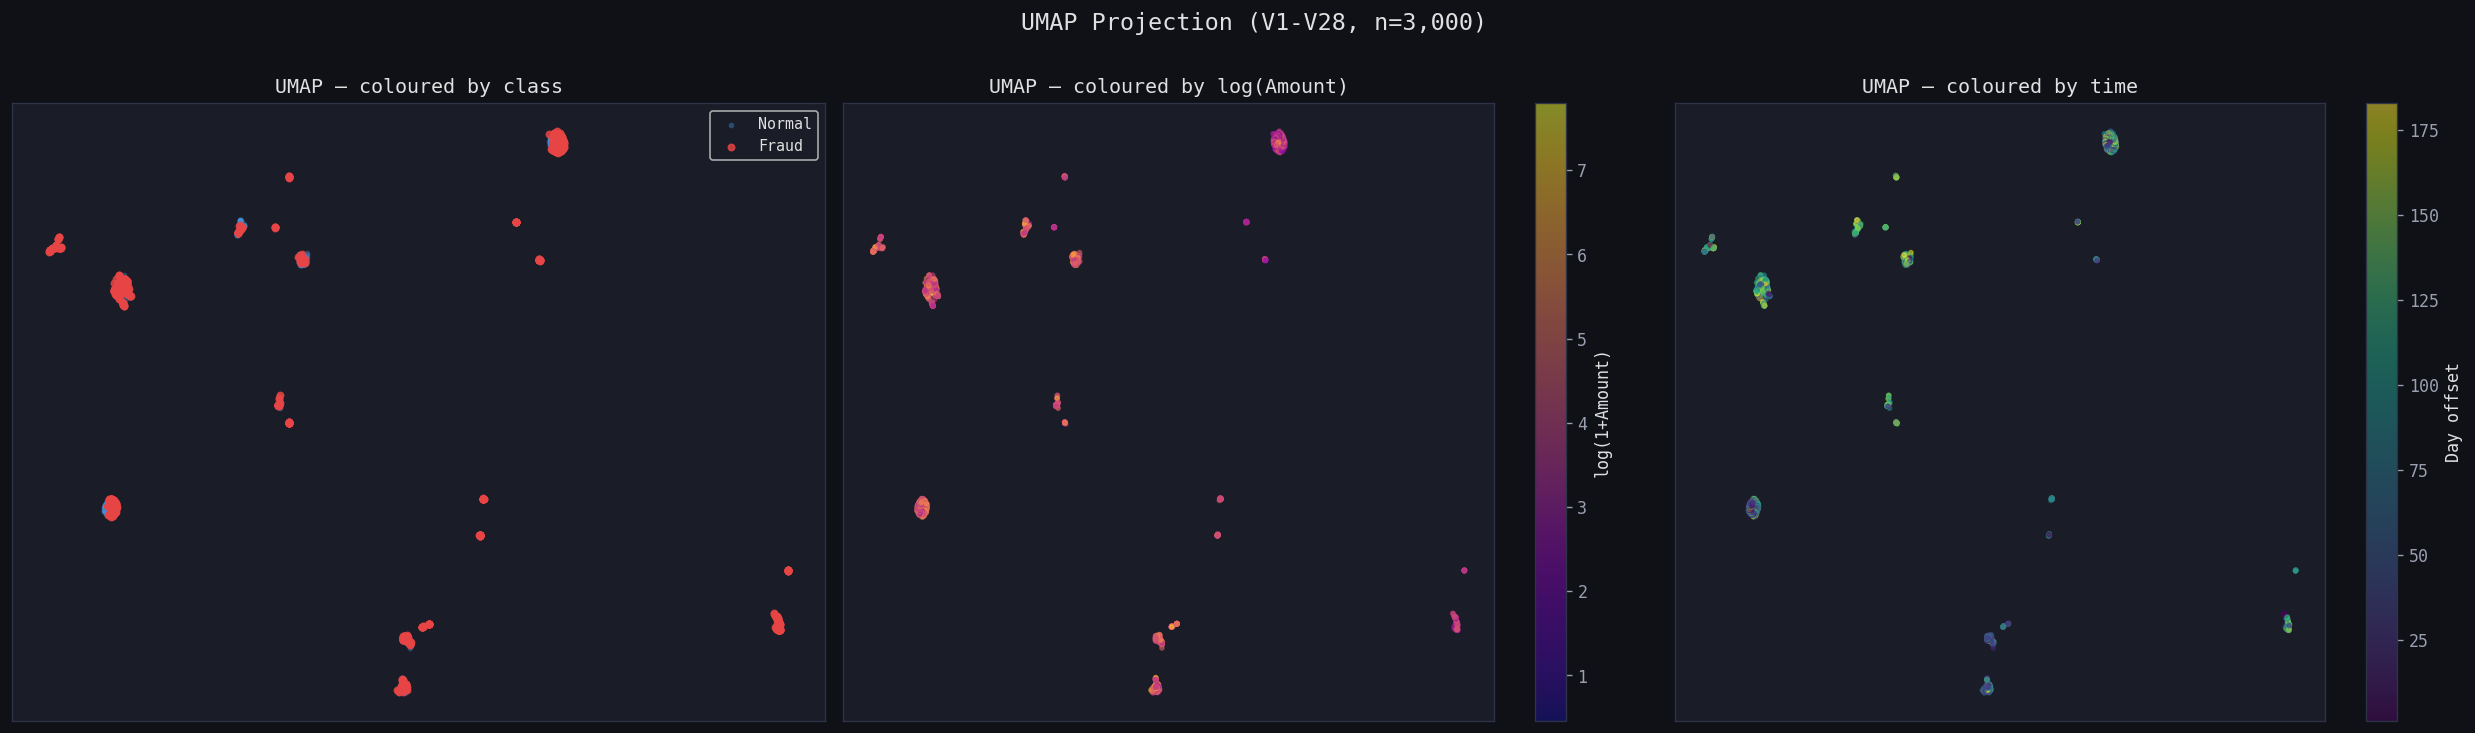

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor("#0F1117")

# Class
axes[0].scatter(Z_umap[mask_n,0], Z_umap[mask_n,1], c=PAL["normal"], s=6,  alpha=0.3, label="Normal")
axes[0].scatter(Z_umap[mask_f,0], Z_umap[mask_f,1], c=PAL["fraud"],  s=14, alpha=0.8, label="Fraud")
axes[0].set_title("UMAP — coloured by class", color="#E0E0E0"); axes[0].legend(fontsize=9)
axes[0].set_xticks([]); axes[0].set_yticks([])

# Amount
sc2 = axes[1].scatter(Z_umap[:,0], Z_umap[:,1], c=amt_sample, cmap="plasma", s=6, alpha=0.5)
plt.colorbar(sc2, ax=axes[1], label="log(1+Amount)")
axes[1].set_title("UMAP — coloured by log(Amount)", color="#E0E0E0")
axes[1].set_xticks([]); axes[1].set_yticks([])

# Day offset
day_sample = df.iloc[idx]["Time"].values / 86400
sc3 = axes[2].scatter(Z_umap[:,0], Z_umap[:,1], c=day_sample, cmap="viridis", s=6, alpha=0.5)
plt.colorbar(sc3, ax=axes[2], label="Day offset")
axes[2].set_title("UMAP — coloured by time", color="#E0E0E0")
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle("UMAP Projection (V1-V28, n=3,000)", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


## 11 · UMAP with engineered features

UMAP with 32 features (V1-V28 + 4 engineered) ...
Done in 8.3s


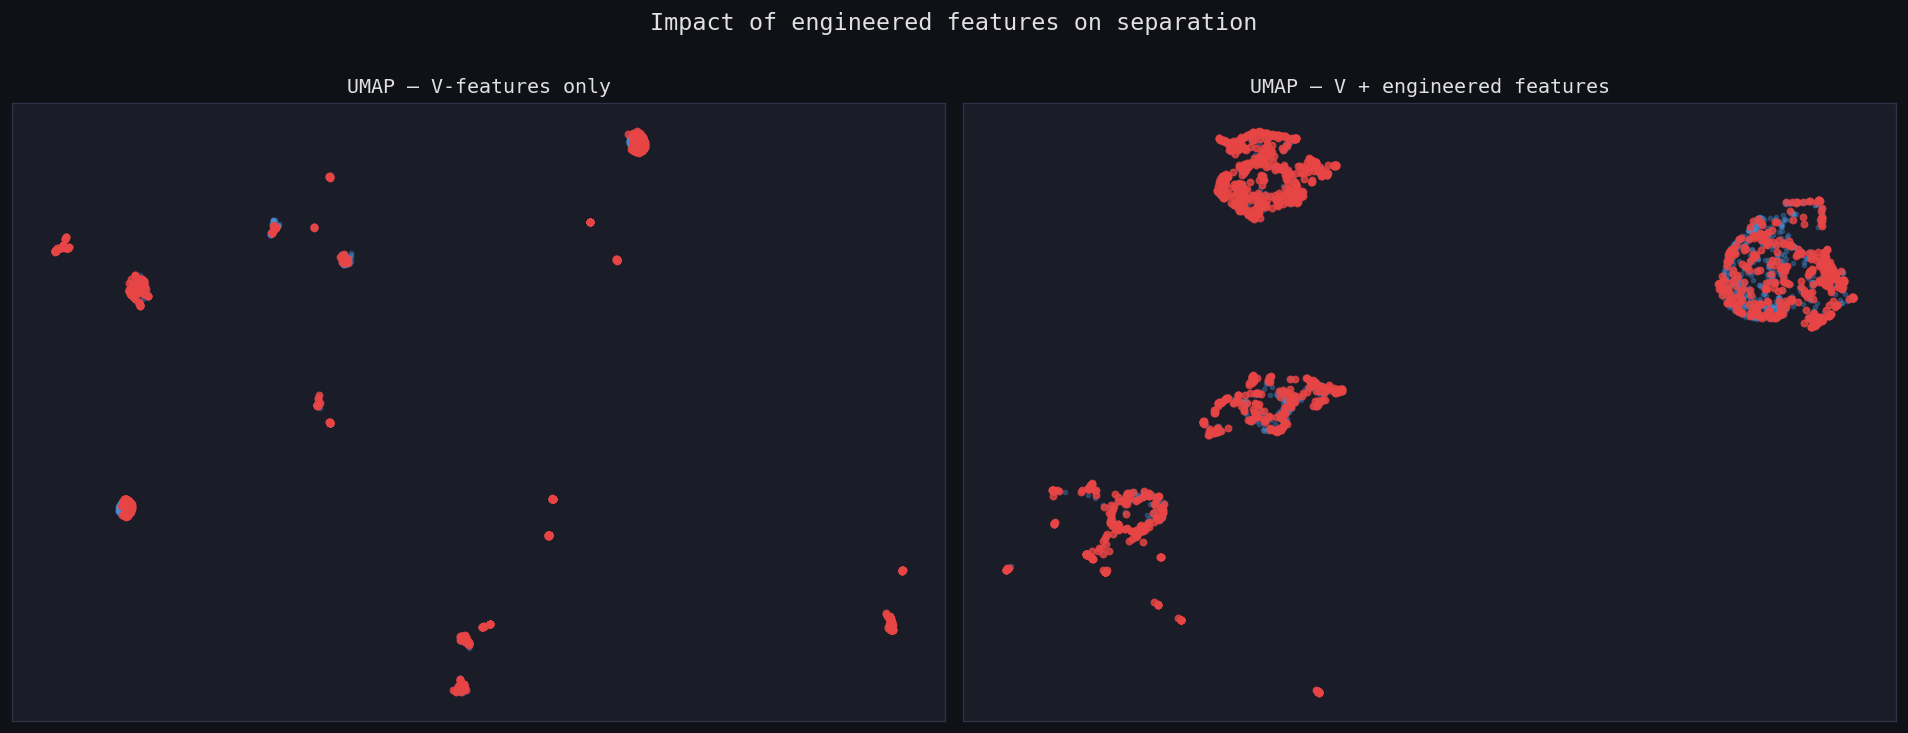

In [17]:
# Re-run UMAP including engineered features for comparison
df_s = df.iloc[idx].copy()
df_s["log_amount"] = np.log1p(df_s["Amount"].fillna(0))
df_s["time_delta"] = df_s.groupby("user_id")["Time"].diff().fillna(0)
df_s["rolling_mean_3"] = df_s.groupby("user_id")["log_amount"].transform(
    lambda x: x.rolling(3, min_periods=1).mean())
df_s["amount_vs_mean"] = df_s["log_amount"] - df_s["rolling_mean_3"]

all_feats = [c for c in df_s.columns if c.startswith("V")][:28] +             ["log_amount","time_delta","rolling_mean_3","amount_vs_mean"]
X_eng = np.clip(RobustScaler().fit_transform(df_s[all_feats].fillna(0).values), -5, 5)

print(f"UMAP with {len(all_feats)} features (V1-V28 + 4 engineered) ...")
t0 = time.time()
Z_eng = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                  random_state=42, n_jobs=-1).fit_transform(X_eng)
print(f"Done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0F1117")
axes[0].scatter(Z_umap[mask_n,0], Z_umap[mask_n,1], c=PAL["normal"], s=6, alpha=0.3)
axes[0].scatter(Z_umap[mask_f,0], Z_umap[mask_f,1], c=PAL["fraud"],  s=14, alpha=0.8)
axes[0].set_title("UMAP — V-features only", color="#E0E0E0")
axes[0].set_xticks([]); axes[0].set_yticks([])

axes[1].scatter(Z_eng[mask_n,0], Z_eng[mask_n,1], c=PAL["normal"], s=6, alpha=0.3)
axes[1].scatter(Z_eng[mask_f,0], Z_eng[mask_f,1], c=PAL["fraud"],  s=14, alpha=0.8)
axes[1].set_title("UMAP — V + engineered features", color="#E0E0E0")
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.suptitle("Impact of engineered features on separation", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


## 12 · Engineered feature analysis

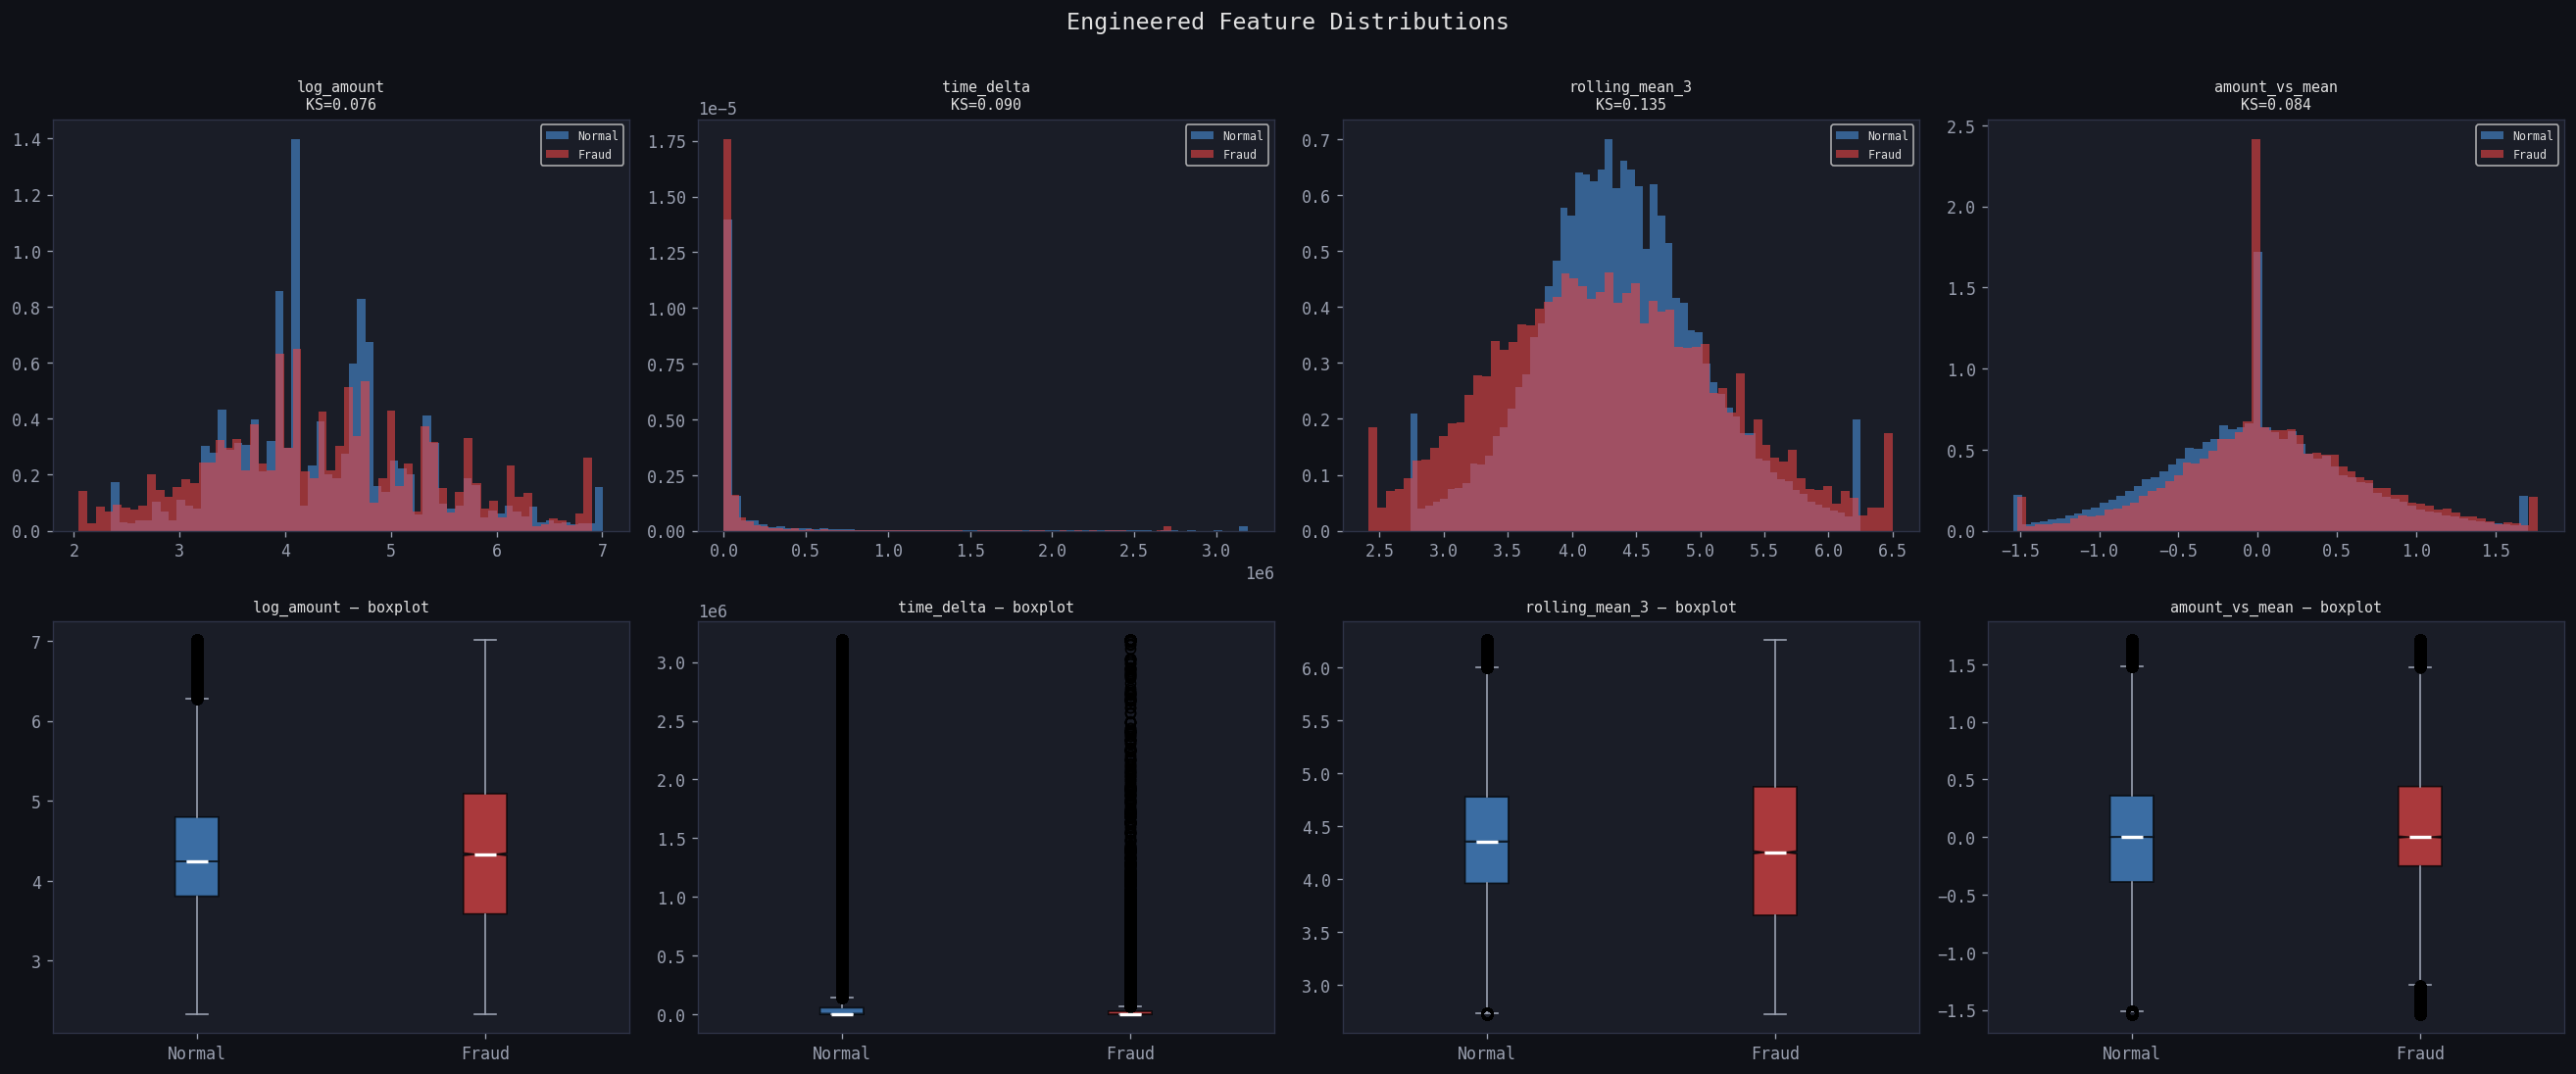

In [18]:
df["log_amount"] = np.log1p(df["Amount"].fillna(0))
df["time_delta"] = df.groupby("user_id")["Time"].diff().fillna(0)
df["rolling_mean_3"] = df.groupby("user_id")["log_amount"].transform(
    lambda x: x.rolling(3, min_periods=1).mean())
df["amount_vs_mean"] = df["log_amount"] - df["rolling_mean_3"]

eng_feats = ["log_amount","time_delta","rolling_mean_3","amount_vs_mean"]
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.patch.set_facecolor("#0F1117")

for col_idx, feat in enumerate(eng_feats):
    for cls, lbl, clr in [(0,"Normal",PAL["normal"]),(1,"Fraud",PAL["fraud"])]:
        vals = df[df["Class"]==cls][feat].dropna()
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        axes[0, col_idx].hist(vals.clip(lo, hi), bins=60, alpha=0.6,
                              color=clr, label=lbl, density=True)
    ks_s, _ = stats.ks_2samp(
        df[df["Class"]==0][feat].dropna(),
        df[df["Class"]==1][feat].dropna())
    axes[0, col_idx].set_title(f"{feat}\nKS={ks_s:.3f}", color="#E0E0E0", fontsize=9)
    axes[0, col_idx].legend(fontsize=7)

    # Box plot in row 2
    data_n = df[df["Class"]==0][feat].dropna().clip(
        df[feat].quantile(0.01), df[feat].quantile(0.99))
    data_f = df[df["Class"]==1][feat].dropna().clip(
        df[feat].quantile(0.01), df[feat].quantile(0.99))
    bp = axes[1, col_idx].boxplot([data_n, data_f], labels=["Normal","Fraud"],
                                   patch_artist=True, notch=True,
                                   medianprops={"color":"white","lw":2})
    for patch, clr in zip(bp["boxes"], [PAL["normal"], PAL["fraud"]]):
        patch.set_facecolor(clr); patch.set_alpha(0.7)
    for element in ["whiskers","caps","fliers"]:
        for line in bp[element]: line.set_color("#9AA0B0")
    axes[1, col_idx].set_title(f"{feat} — boxplot", color="#E0E0E0", fontsize=9)

plt.suptitle("Engineered Feature Distributions", fontsize=14, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


## 13 · Key findings summary

In [19]:
print("=" * 55)
print("EDA KEY FINDINGS")
print("=" * 55)
print(f"Dataset      : {len(df):,} transactions over {df['Time'].max()/86400:.0f} days")
print(f"Fraud rate   : {df['Class'].mean()*100:.3f}%  ({df['Class'].sum():,} fraud tx)")
print(f"Unique cards : {df['user_id'].nunique():,}")
print()
print("Top KS features vs fraud label:")
for _, row in ks_df.head(5).iterrows():
    print(f"  {row['feature']:<8}  KS={row['ks_stat']:.3f}")
print()
print(f"Peak fraud hour   : {hourly.idxmax()}:00 ({hourly.max():.2f}%)")
print(f"Lowest fraud hour : {hourly.idxmin()}:00 ({hourly.min():.2f}%)")
print()
print("Cards with >=1 fraud tx:", f"{(card_fraud_rate>0).sum():,}")
print("Cards that are >50% fraud:", f"{(card_fraud_rate>0.5).sum():,}")
print()
amt_corr = abs(np.corrcoef(df["log_amount"], df["Class"])[0,1])
print(f"log(Amount) vs isFraud correlation: {amt_corr:.4f}")
print("=" * 55)


EDA KEY FINDINGS
Dataset      : 590,540 transactions over 183 days
Fraud rate   : 3.499%  (20,663 fraud tx)
Unique cards : 13,553

Top KS features vs fraud label:
  V15       KS=0.327
  V16       KS=0.326
  V18       KS=0.318
  V17       KS=0.318
  V22       KS=0.315

Peak fraud hour   : 7:00 (10.61%)
Lowest fraud hour : 13:00 (2.29%)

Cards with >=1 fraud tx: 1,740
Cards that are >50% fraud: 288

log(Amount) vs isFraud correlation: 0.0018
